In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_rotate_45_augmented_flip_horizontal_img153_jpg.rf.d6c9a2cfc14449739cfa3c7dc44ca885.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img360_jpg.rf.1174acba2e2bfffbbfa4c1cd63009ba3.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img476.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_img819_jpg.rf.a56ae5f661f572775d4e3ec9859633a6.jpg
/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmente

In [2]:
!pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models

from torch.utils.data import Dataset, DataLoader

import cv2
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [3]:
import os

print(os.listdir("/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split"))

['valid', 'test', 'train']


In [5]:
DATASET_ROOT = "/kaggle/input/datasets/dhirajkumarbalamanik/dataset-split/dataset_split"

TRAIN_PATH = DATASET_ROOT + "/train"
VAL_PATH   = DATASET_ROOT + "/valid"
TEST_PATH  = DATASET_ROOT + "/test"

In [6]:
import os

print(os.listdir(TRAIN_PATH))

['Second Degree Burn Partial of Intermediate Thickness', 'Third Degree Burn Full hickness', 'First Degree Burn Superficial Thickness', 'No Sunburn']


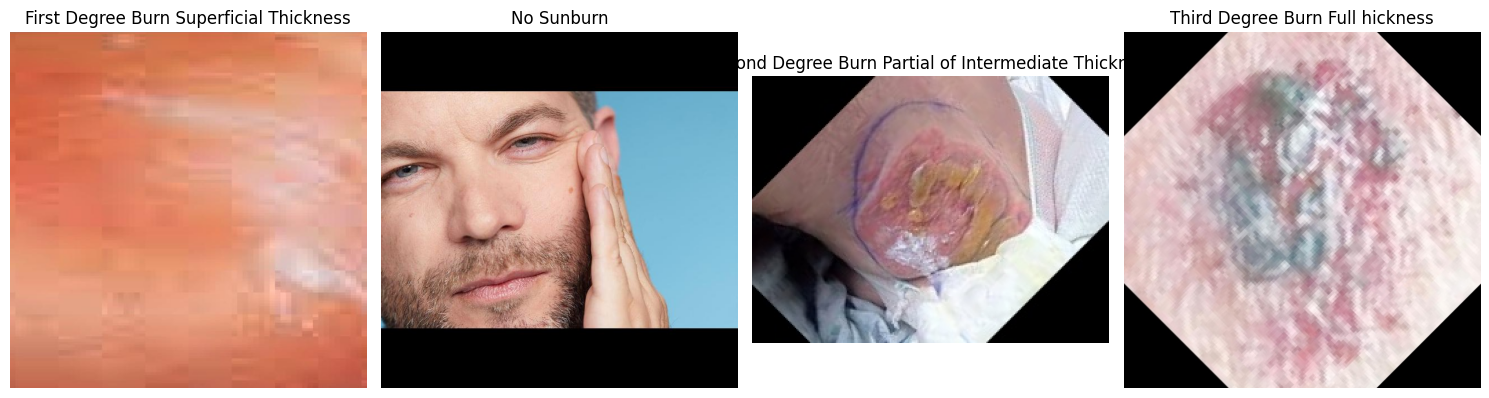

In [7]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

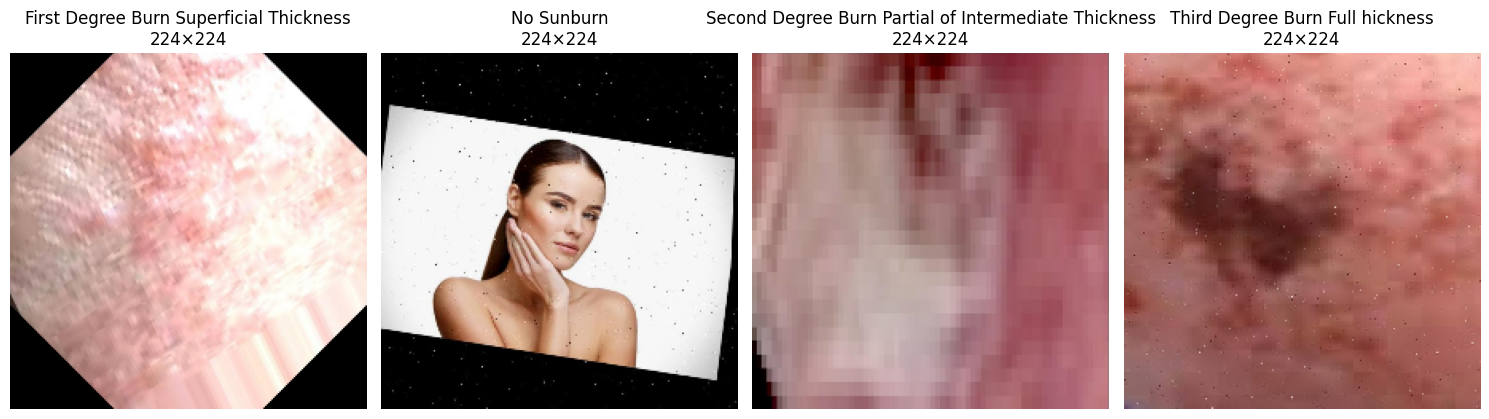

In [9]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ✅ RESIZE TO 224x224
        img = cv2.resize(img, (224, 224))

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.title(f"{class_name}\n224×224")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

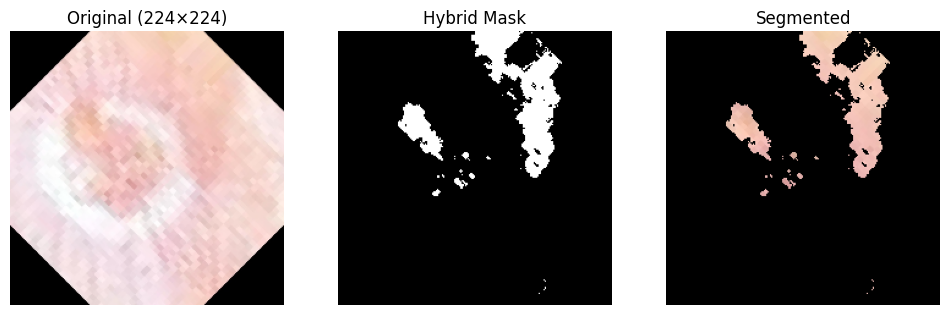

In [10]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

def hybrid_skin_mask(image):
    img = image.astype(np.float32)

    # RGB RULE
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    rgb_mask = (
        (R > 95) &
        (G > 40) &
        (B > 20) &
        ((np.max(img, axis=2) - np.min(img, axis=2)) > 15) &
        (np.abs(R - G) > 15) &
        (R > G) &
        (R > B)
    ).astype(np.uint8)

    # HSV RULE
    hsv = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_RGB2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    hsv_mask = (
        (H >= 0) & (H <= 50) &
        (S >= 0.23 * 255) & (S <= 0.68 * 255) &
        (V >= 0.35 * 255)
    ).astype(np.uint8)

    # HYBRID
    final_mask = cv2.bitwise_and(rgb_mask, hsv_mask)

    return final_mask * 255


def get_random_image(train_path):
    all_images = []

    for root, _, files in os.walk(train_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                all_images.append(os.path.join(root, file))

    return random.choice(all_images)


def show_hybrid_segmentation(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    mask = hybrid_skin_mask(img)
    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Hybrid Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Segmented")
    plt.axis("off")

    plt.show()


# ---- RUN ----
img_path = get_random_image(TRAIN_PATH)
show_hybrid_segmentation(img_path)

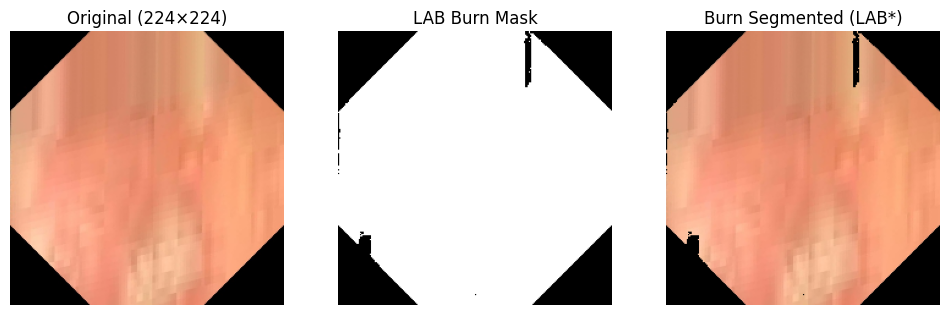

In [11]:
import cv2
import numpy as np

def lab_burn_mask(image):
    # Convert RGB → LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0]
    A = lab[:, :, 1]
    B = lab[:, :, 2]

    # Normalize (optional but improves stability)
    L = L / 255.0
    A = A / 255.0
    B = B / 255.0

    # -----------------------------
    # BURN RULE (heuristic)
    # -----------------------------
    burn_mask = (
        (A > 0.55) &      # strong redness
        (L > 0.2) & (L < 0.85)  # avoid extreme dark/light regions
    )

    return (burn_mask.astype(np.uint8) * 255)

import os, random

def get_random_image(path):
    imgs = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg','.png','.jpeg')):
                imgs.append(os.path.join(root, f))
    return random.choice(imgs)

import matplotlib.pyplot as plt

def show_lab_burn_segmentation(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    mask = lab_burn_mask(img)

    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("LAB Burn Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Burn Segmented (LAB*)")
    plt.axis("off")

    plt.show()

img_path = get_random_image(TRAIN_PATH)
show_lab_burn_segmentation(img_path)

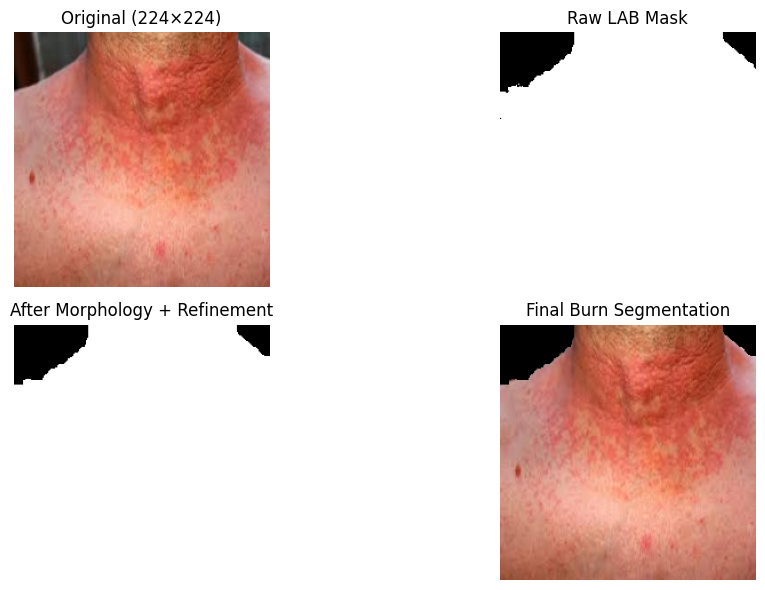

In [12]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt


# -------------------------
# RANDOM IMAGE LOADER
# -------------------------
def get_random_image(path):
    imgs = []

    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                imgs.append(os.path.join(root, f))

    if len(imgs) == 0:
        raise ValueError("No images found in the given path")

    return random.choice(imgs)


# -------------------------
# LAB BURN MASK
# -------------------------
def lab_burn_mask(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0] / 255.0
    A = lab[:, :, 1] / 255.0

    mask = (
        (A > 0.55) &
        (L > 0.2) & (L < 0.85)
    )

    return (mask.astype(np.uint8) * 255)


# -------------------------
# MORPHOLOGY CLEANING
# -------------------------
def post_process_mask(mask):
    kernel = np.ones((5,5), np.uint8)

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

    return closed


# -------------------------
# EXTRA REFINEMENT
# -------------------------
def refine_mask(mask):
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return mask


# -------------------------
# MAIN PIPELINE
# -------------------------
def show_pipeline(train_path):
    # Step 1: Load image
    img_path = get_random_image(train_path)

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Step 2: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 3: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 4: Extra refinement
    clean_mask = refine_mask(clean_mask)

    # Step 5: Segmentation
    raw_seg = cv2.bitwise_and(img, img, mask=raw_mask)
    clean_seg = cv2.bitwise_and(img, img, mask=clean_mask)

    # Step 6: Plot
    plt.figure(figsize=(12,6))

    plt.subplot(2,2,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(raw_mask, cmap="gray")
    plt.title("Raw LAB Mask")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("After Morphology + Refinement")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(clean_seg)
    plt.title("Final Burn Segmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------
# RUN
# -------------------------
show_pipeline(TRAIN_PATH)

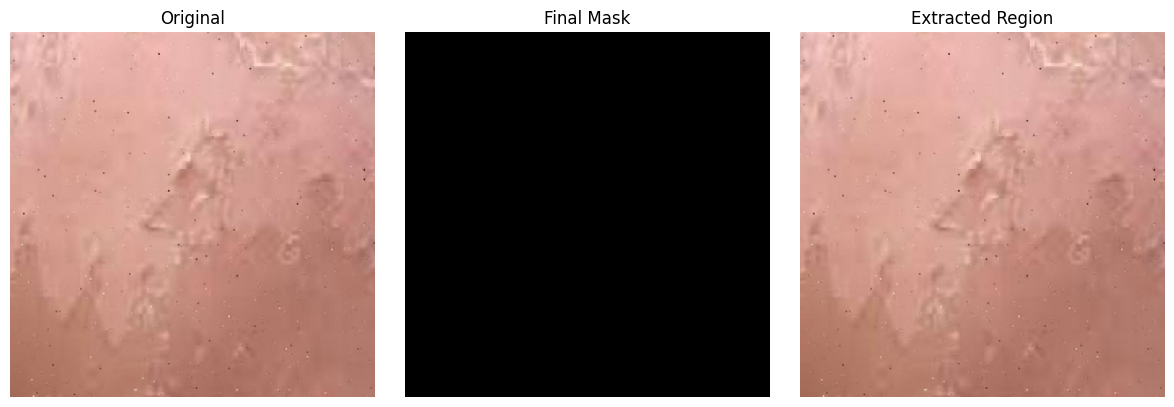

In [13]:
def extract_region(image, mask):
    # ensure mask is binary
    mask = (mask > 0).astype(np.uint8) * 255

    # extract region
    extracted = cv2.bitwise_and(image, image, mask=mask)

    return extracted

def show_region_extraction(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Step 1: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 2: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 3: Region extraction
    extracted = extract_region(img, clean_mask)

    # Plot
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Final Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted)
    plt.title("Extracted Region")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
show_region_extraction(TRAIN_PATH)

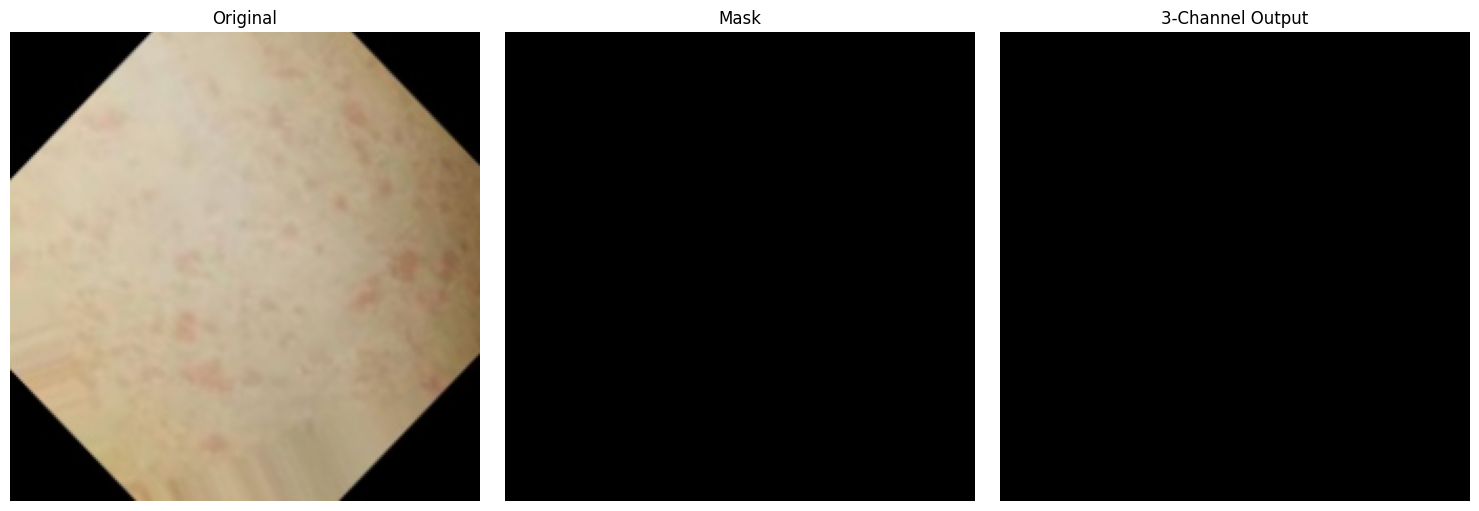

In [14]:
import cv2
import numpy as np

def extract_3channel_region(image, mask):
    # ensure binary mask
    mask = (mask > 0).astype(np.uint8)

    # expand mask to 3 channels
    mask_3ch = np.stack([mask, mask, mask], axis=-1)

    # apply mask
    output = image * mask_3ch

    return output

import matplotlib.pyplot as plt

def show_3channel_pipeline(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # LAB segmentation
    raw_mask = lab_burn_mask(img)

    # Morphology cleanup
    clean_mask = post_process_mask(raw_mask)

    # 3-channel output
    extracted_3ch = extract_3channel_region(img, clean_mask)

    # Visualization
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted_3ch)
    plt.title("3-Channel Output")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_3channel_pipeline(TRAIN_PATH)

Total images: 10817
Loading image...


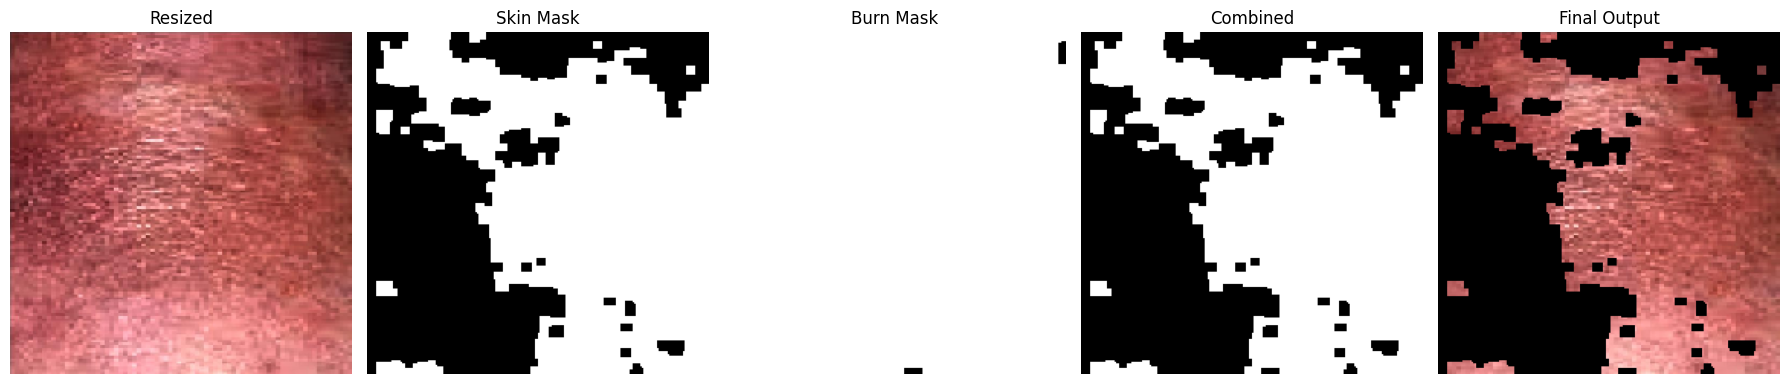

In [15]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# LOAD ALL IMAGES (FAST)
# -------------------------
ALL_IMAGES = []

for root, _, files in os.walk(TRAIN_PATH):
    for f in files:
        if f.lower().endswith(('.jpg', '.png', '.jpeg')):
            ALL_IMAGES.append(os.path.join(root, f))

print("Total images:", len(ALL_IMAGES))


def get_random_image_fast():
    if len(ALL_IMAGES) == 0:
        raise ValueError("No images found!")
    return random.choice(ALL_IMAGES)


# -------------------------
# PIPELINE FUNCTIONS
# -------------------------

def resize(img):
    return cv2.resize(img, (224, 224))


def skin_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    mask = (
        (H < 50) &
        (S > 0.2 * 255) & (S < 0.7 * 255) &
        (V > 0.35 * 255)
    )

    return (mask.astype(np.uint8) * 255)


def burn_mask(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0] / 255.0
    A = lab[:, :, 1] / 255.0

    mask = (
        (A > 0.55) &
        (L > 0.2) & (L < 0.85)
    )

    return (mask.astype(np.uint8) * 255)


def clean(mask):
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def combine(skin, burn):
    return cv2.bitwise_and(skin, burn)


def extract(img, mask):
    return cv2.bitwise_and(img, img, mask=mask)


# -------------------------
# MAIN PIPELINE
# -------------------------
def full_pipeline_fast():

    print("Loading image...")

    img_path = get_random_image_fast()

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Step 1: Resize ---
    img = resize(img)

    # --- Step 2: Skin Mask ---
    skin = skin_mask(img)

    # --- Step 3: Burn Mask ---
    burn = burn_mask(img)

    # --- Step 4: Clean ---
    skin = clean(skin)
    burn = clean(burn)

    # --- Step 5: Combine ---
    combined = combine(skin, burn)

    # --- Step 6: Extract ---
    final = extract(img, combined)

    # --- Display ---
    plt.figure(figsize=(18,6))

    plt.subplot(1,5,1)
    plt.imshow(img)
    plt.title("Resized")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(skin, cmap="gray")
    plt.title("Skin Mask")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(burn, cmap="gray")
    plt.title("Burn Mask")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(combined, cmap="gray")
    plt.title("Combined")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(final)
    plt.title("Final Output")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------
# RUN
# -------------------------
full_pipeline_fast()

In [47]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import Inception_V3_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("✅ GPU:", torch.cuda.get_device_name(0))
else:
    print("❌ Running on CPU")

✅ GPU: Tesla T4


In [49]:
def print_gpu_usage():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"GPU Memory Allocated: {allocated:.2f} GB")
        print(f"GPU Memory Reserved : {reserved:.2f} GB")

In [50]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [51]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [52]:
model = models.inception_v3(weights=Inception_V3_Weights.DEFAULT)

# ✅ disable auxiliary branch (important for 224)
model.aux_logits = False
model.AuxLogits = None

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [54]:
best_val_loss = float('inf')
patience = 10
counter = 0

In [55]:
num_epochs = 100

train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

for epoch in range(num_epochs):

    epoch_start = time.time()

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    epoch_time = time.time() - epoch_start

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    print(f"⏱️ Epoch Time: {epoch_time:.2f} sec")

    print_gpu_usage()

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("🚀 Early stopping triggered!")
            break

end_time = time.time()


Epoch [1/100]
Train Loss: 0.5664, Train Acc: 0.7704
Val   Loss: 0.3479, Val   Acc: 0.8631
⏱️ Epoch Time: 180.22 sec
GPU Memory Allocated: 3.33 GB
GPU Memory Reserved : 5.59 GB

Epoch [2/100]
Train Loss: 0.3076, Train Acc: 0.8809
Val   Loss: 0.2805, Val   Acc: 0.9020
⏱️ Epoch Time: 170.13 sec
GPU Memory Allocated: 3.33 GB
GPU Memory Reserved : 5.59 GB

Epoch [3/100]
Train Loss: 0.2264, Train Acc: 0.9182
Val   Loss: 0.2770, Val   Acc: 0.8955
⏱️ Epoch Time: 167.31 sec
GPU Memory Allocated: 3.33 GB
GPU Memory Reserved : 5.59 GB

Epoch [4/100]
Train Loss: 0.1652, Train Acc: 0.9434
Val   Loss: 0.2683, Val   Acc: 0.9162
⏱️ Epoch Time: 167.89 sec
GPU Memory Allocated: 3.33 GB
GPU Memory Reserved : 5.59 GB

Epoch [5/100]
Train Loss: 0.1463, Train Acc: 0.9459
Val   Loss: 0.2622, Val   Acc: 0.9136
⏱️ Epoch Time: 171.16 sec
GPU Memory Allocated: 3.33 GB
GPU Memory Reserved : 5.59 GB

Epoch [6/100]
Train Loss: 0.1306, Train Acc: 0.9517
Val   Loss: 0.2859, Val   Acc: 0.9076
⏱️ Epoch Time: 170.90 se

In [56]:
total_time = end_time - start_time
print(f"\n⏱️ Total Training Time: {total_time/60:.2f} minutes")


⏱️ Total Training Time: 43.38 minutes


In [57]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_acc = correct / total

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.3133
Test Accuracy: 0.9036


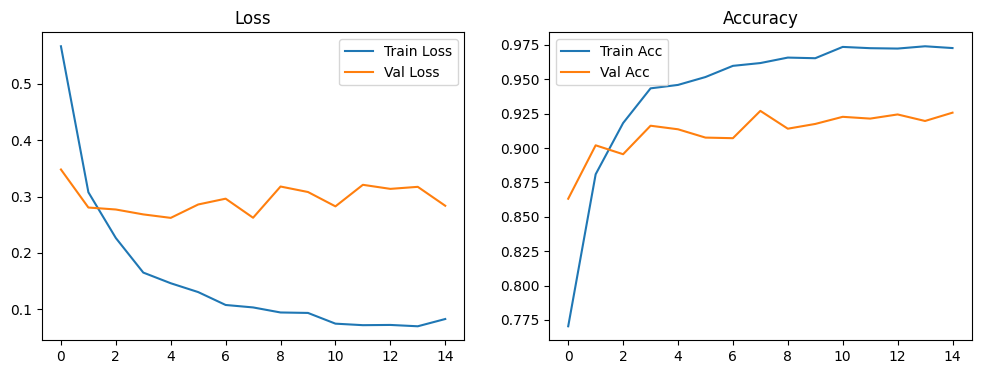

In [58]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

In [59]:
import torch
import psutil
import os

In [63]:
def get_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        return allocated, reserved
    return 0, 0


def get_ram_usage():
    process = psutil.Process(os.getpid())
    ram = process.memory_info().rss / 1024**3
    return ram

In [67]:
max_gpu_allocated = 0
max_gpu_reserved = 0
max_ram = 0

In [68]:
# --- Track usage ---
gpu_alloc, gpu_res = get_gpu_memory()
ram = get_ram_usage()

max_gpu_allocated = max(max_gpu_allocated, gpu_alloc)
max_gpu_reserved = max(max_gpu_reserved, gpu_res)
max_ram = max(max_ram, ram)

print(f"GPU Allocated: {gpu_alloc:.2f} GB")
print(f"GPU Reserved : {gpu_res:.2f} GB")
print(f"RAM Usage    : {ram:.2f} GB")

GPU Allocated: 3.34 GB
GPU Reserved : 5.59 GB
RAM Usage    : 1.89 GB


In [69]:
print("\n🔥 ===== FINAL RESOURCE USAGE =====")

print(f"✅ Max GPU Allocated : {max_gpu_allocated:.2f} GB")
print(f"✅ Max GPU Reserved  : {max_gpu_reserved:.2f} GB")
print(f"✅ Max RAM Used      : {max_ram:.2f} GB")


🔥 ===== FINAL RESOURCE USAGE =====
✅ Max GPU Allocated : 3.34 GB
✅ Max GPU Reserved  : 5.59 GB
✅ Max RAM Used      : 1.89 GB


In [71]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [72]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [73]:
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

print("\n🔥 Confusion Matrix:\n")
print(cm)


🔥 Confusion Matrix:

[[420   0  75   1]
 [  1 146   1   0]
 [ 43   1 879  36]
 [  6   0  60 654]]


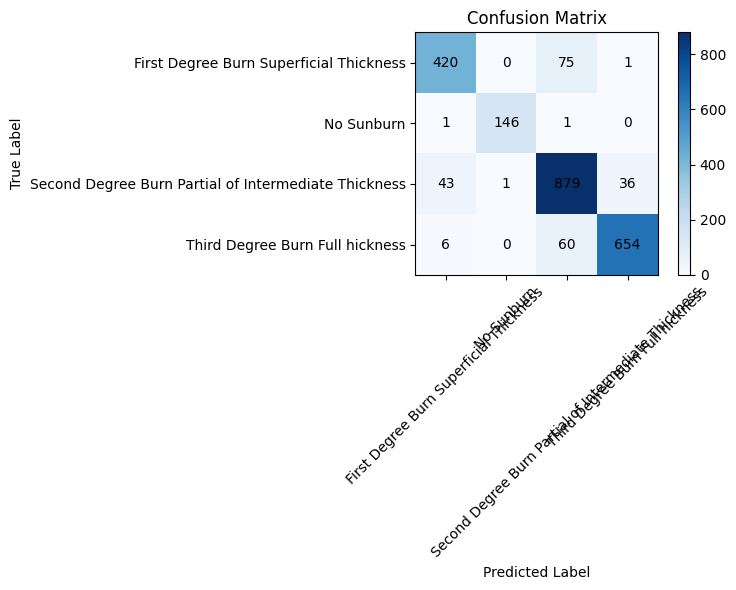

In [74]:
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")

plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# numbers inside boxes
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [75]:
print("\n🔥 Classification Report:\n")

report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)


🔥 Classification Report:

                                                      precision    recall  f1-score   support

             First Degree Burn Superficial Thickness       0.89      0.85      0.87       496
                                          No Sunburn       0.99      0.99      0.99       148
Second Degree Burn Partial of Intermediate Thickness       0.87      0.92      0.89       959
                     Third Degree Burn Full hickness       0.95      0.91      0.93       720

                                            accuracy                           0.90      2323
                                           macro avg       0.92      0.91      0.92      2323
                                        weighted avg       0.90      0.90      0.90      2323



In [79]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [80]:
cm = confusion_matrix(all_labels, all_preds)

# ✅ Normalize (row-wise)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\n🔥 Normalized Confusion Matrix:\n")
print(cm_norm)


🔥 Normalized Confusion Matrix:

[[0.84677419 0.         0.15120968 0.00201613]
 [0.00675676 0.98648649 0.00675676 0.        ]
 [0.04483837 0.00104275 0.91657977 0.0375391 ]
 [0.00833333 0.         0.08333333 0.90833333]]


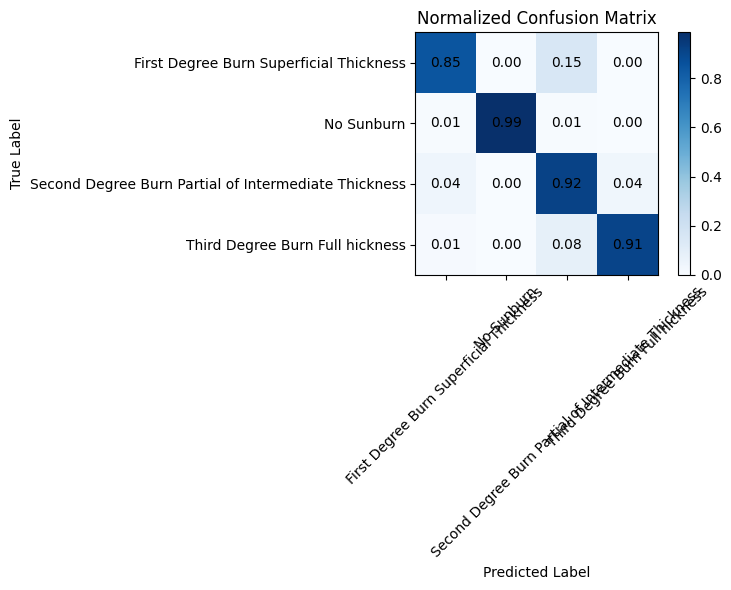

In [81]:
class_names = train_dataset.classes

plt.figure(figsize=(8,6))
plt.imshow(cm_norm, cmap="Blues")

plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

# 🔢 show values inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", 
                 ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [82]:
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

# ✅ Per-class accuracy = diagonal / row sum
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("\n Per-Class Accuracy:\n")
for i, acc in enumerate(per_class_acc):
    print(f"{class_names[i]}: {acc:.4f}")


 Per-Class Accuracy:

First Degree Burn Superficial Thickness: 0.8468
No Sunburn: 0.9865
Second Degree Burn Partial of Intermediate Thickness: 0.9166
Third Degree Burn Full hickness: 0.9083


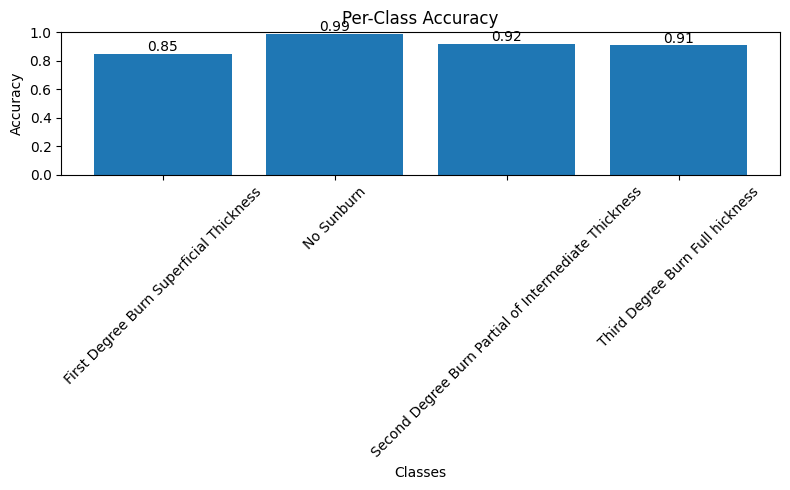

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(class_names, per_class_acc)

plt.title("Per-Class Accuracy")
plt.xlabel("Classes")
plt.ylabel("Accuracy")

plt.ylim(0, 1)  # accuracy range

# show values on top
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [84]:
# Final values from training history
final_train_acc = train_accs[-1]
final_val_acc   = val_accs[-1]

# Test accuracy (already computed)
# make sure test_acc exists
print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9727
Validation Accuracy: 0.9257
Test Accuracy: 0.9036


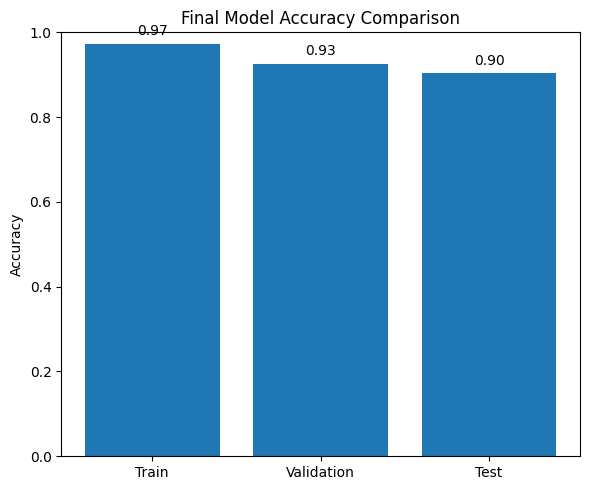

In [85]:
import matplotlib.pyplot as plt

labels = ['Train', 'Validation', 'Test']
accuracies = [final_train_acc, final_val_acc, test_acc]

plt.figure(figsize=(6,5))

plt.bar(labels, accuracies)

plt.title("Final Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# show values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(loader):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec  = recall_score(all_labels, all_preds, average='weighted')
    f1   = f1_score(all_labels, all_preds, average='weighted')

    return acc, prec, rec, f1

In [89]:
train_acc, train_prec, train_rec, train_f1 = compute_metrics(train_loader)
val_acc, val_prec, val_rec, val_f1         = compute_metrics(val_loader)
test_acc, test_prec, test_rec, test_f1     = compute_metrics(test_loader)

print("\n TRAIN METRICS")
print(train_acc, train_prec, train_rec, train_f1)

print("\n VALIDATION METRICS")
print(val_acc, val_prec, val_rec, val_f1)

print("\n TEST METRICS")
print(test_acc, test_prec, test_rec, test_f1)


 TRAIN METRICS
0.971341407044467 0.9714137489939998 0.971341407044467 0.9713622574652941

 VALIDATION METRICS
0.9136442141623489 0.9142015229974203 0.9136442141623489 0.9137712397910491

 TEST METRICS
0.9035729659922515 0.9049409669009295 0.9035729659922515 0.9037040997403175


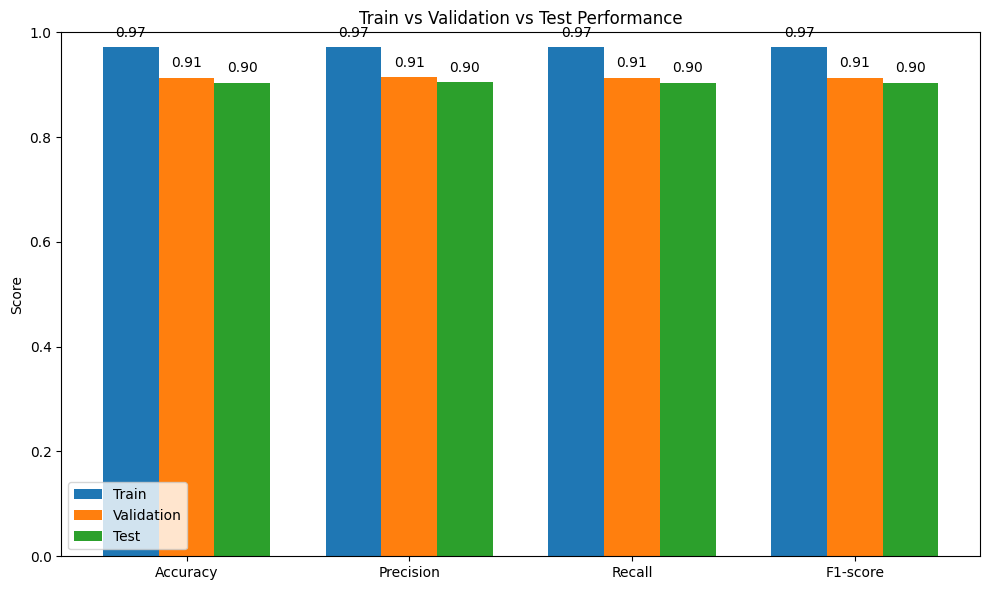

In [90]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

train_values = [train_acc, train_prec, train_rec, train_f1]
val_values   = [val_acc, val_prec, val_rec, val_f1]
test_values  = [test_acc, test_prec, test_rec, test_f1]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, train_values, width, label='Train')
plt.bar(x,         val_values,   width, label='Validation')
plt.bar(x + width, test_values,  width, label='Test')

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Train vs Validation vs Test Performance")

# value labels
for i in range(len(metrics)):
    plt.text(x[i]-width, train_values[i]+0.02, f"{train_values[i]:.2f}", ha='center')
    plt.text(x[i],       val_values[i]+0.02,   f"{val_values[i]:.2f}", ha='center')
    plt.text(x[i]+width, test_values[i]+0.02,  f"{test_values[i]:.2f}", ha='center')

plt.legend()
plt.tight_layout()
plt.show()

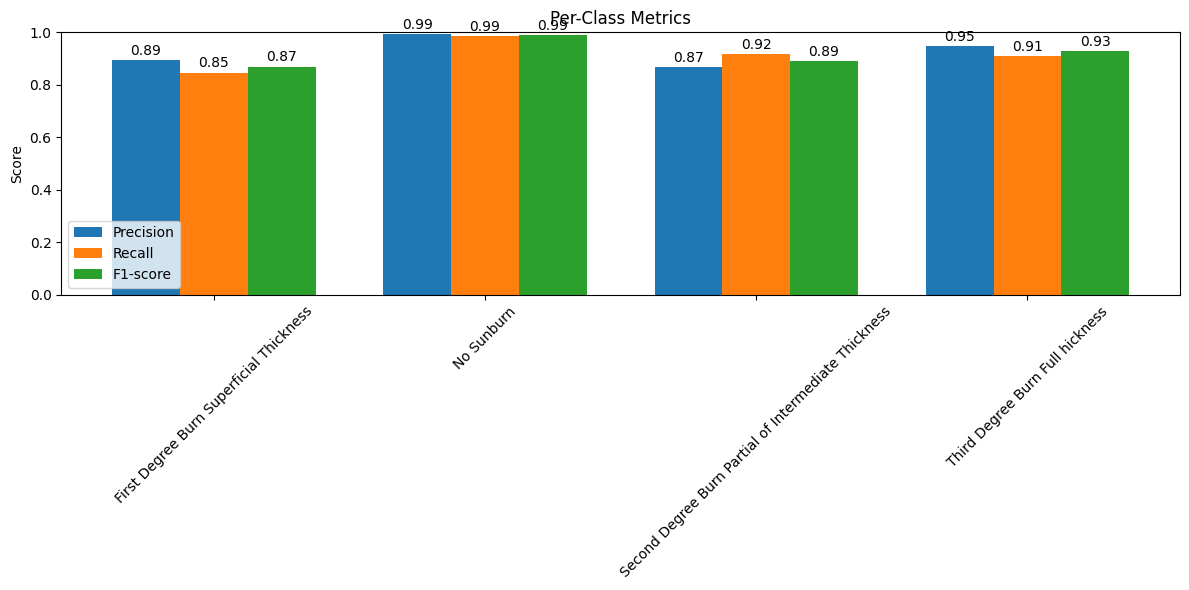

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# ✅ Correct class names
classes = train_dataset.classes

# generate report
report = classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    output_dict=True
)

precision, recall, f1 = [], [], []

for cls in classes:
    precision.append(report[cls]['precision'])
    recall.append(report[cls]['recall'])
    f1.append(report[cls]['f1-score'])

# convert to numpy (optional but clean)
precision = np.array(precision)
recall    = np.array(recall)
f1        = np.array(f1)

# plotting
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x,         recall,    width, label='Recall')
plt.bar(x + width, f1,        width, label='F1-score')

plt.xticks(x, classes, rotation=45)
plt.ylabel("Score")
plt.title("Per-Class Metrics")

plt.ylim(0,1)
plt.legend()

# ✅ add values on bars (important improvement)
for i in range(len(classes)):
    plt.text(i - width, precision[i] + 0.02, f"{precision[i]:.2f}", ha='center')
    plt.text(i,         recall[i] + 0.02,    f"{recall[i]:.2f}", ha='center')
    plt.text(i + width, f1[i] + 0.02,        f"{f1[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [92]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

In [93]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# combine
all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

In [94]:
num_classes = len(train_dataset.classes)

all_labels_bin = label_binarize(all_labels, classes=range(num_classes))

In [96]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

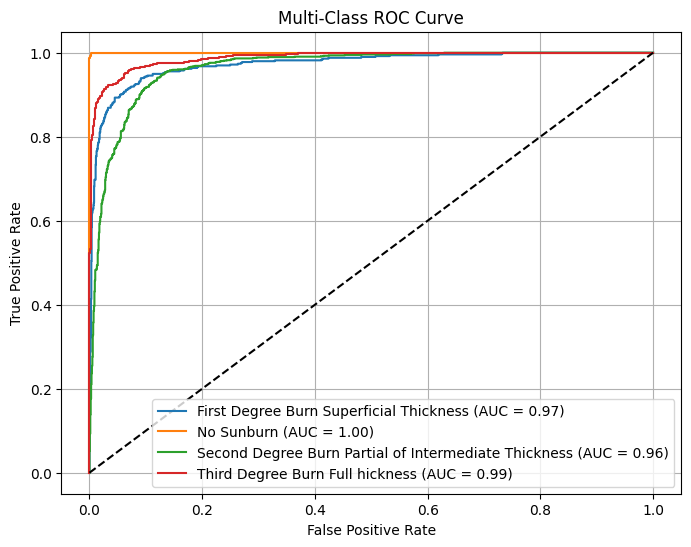

In [97]:
class_names = train_dataset.classes

plt.figure(figsize=(8,6))

for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

# diagonal line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid()

plt.show()

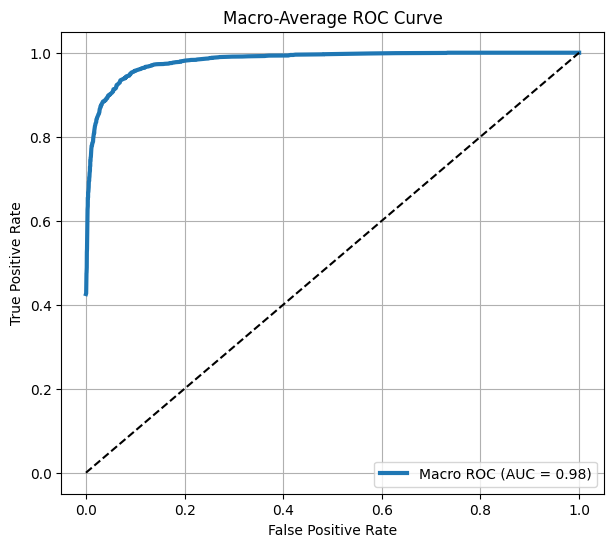


 Macro Average AUC: 0.9815


In [98]:
# ================================
# MULTI-CLASS MACRO ROC CURVE
# ================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------- 1. Collect probabilities --------
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# convert to arrays
all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

# -------- 2. One-hot encode labels --------
num_classes = len(train_dataset.classes)
all_labels_bin = label_binarize(all_labels, classes=range(num_classes))

# -------- 3. Compute ROC for each class --------
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# -------- 4. Compute MACRO average --------
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes

macro_auc = auc(all_fpr, mean_tpr)

# -------- 5. Plot --------
plt.figure(figsize=(7,6))

plt.plot(
    all_fpr,
    mean_tpr,
    linewidth=3,
    label=f"Macro ROC (AUC = {macro_auc:.2f})"
)

# baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")

plt.legend()
plt.grid()
plt.show()

# -------- 6. Print AUC --------
print(f"\n Macro Average AUC: {macro_auc:.4f}")

In [99]:
torch.save(model.state_dict(), "best_model.pth")

In [100]:
model = models.inception_v3(weights=None)   # same architecture

# disable aux (important if you used it)
model.aux_logits = False
model.AuxLogits = None

model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))

model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri